In [ ]:
CSV_FILE = "./03_pertub_density.csv"

In [9]:
from IPython.display import HTML
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv(CSV_FILE)
df.columns = df.columns.str.strip()

timesteps = sorted(df["timestep"].unique())
nx = int(df["x"].max() + 1)
ny = int(df["y"].max() + 1)
num_timesteps = len(timesteps)

rho = np.zeros((num_timesteps, nx, ny))
t_map = {t: i for i, t in enumerate(timesteps)}

for _, row in df.iterrows():
    rho[t_map[row["timestep"]], int(row["x"]), int(row["y"])] = row["density_value"]

FileNotFoundError: [Errno 2] No such file or directory: '04_pertub_density.csv'

In [ ]:
vmin, vmax = rho.min(), rho.max()

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_title(f"{CSV_FILE} — Density Field")
ax.set_xlabel("X"); ax.set_ylabel("Y")

im = ax.imshow(rho[0].T, origin="lower", cmap="viridis", aspect="equal",
               vmin=vmin, vmax=vmax, extent=(-0.5, nx - 0.5, -0.5, ny - 0.5))
cbar = fig.colorbar(im, ax=ax, label="Density")

time_text = ax.text(0.05, 0.93, "", transform=ax.transAxes, color="white", weight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.6))

def update(frame):
    im.set_data(rho[frame].T)
    time_text.set_text(f"Timestep: {timesteps[frame]}")
    return im, time_text

ani = animation.FuncAnimation(fig, update, frames=num_timesteps, interval=120, blit=True)
plt.close(fig)
HTML(ani.to_html5_video())

In [ ]:
slice_y = ny // 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f"{CSV_FILE} — Density Cross-Section at y = {slice_y}")
ax.set_xlabel("X"); ax.set_ylabel("Density")

x_coords = np.arange(nx)
line, = ax.plot(x_coords, rho[0, :, slice_y], "b-")
ax.set_ylim(vmin, vmax)

time_text = ax.text(0.05, 0.93, "", transform=ax.transAxes, color="black", weight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

def update_line(frame):
    line.set_ydata(rho[frame, :, slice_y])
    time_text.set_text(f"Timestep: {timesteps[frame]}")
    return line, time_text

ani_line = animation.FuncAnimation(fig, update_line, frames=num_timesteps, interval=120, blit=True)
plt.close(fig)
HTML(ani_line.to_html5_video())

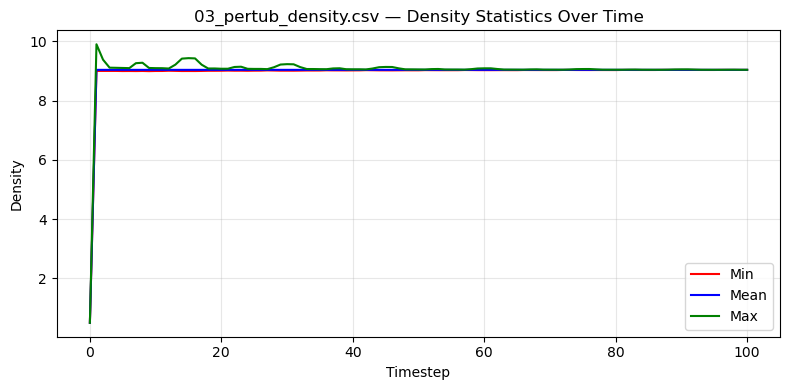

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(timesteps, rho.min(axis=(1, 2)), label="Min", color="red")
ax.plot(timesteps, rho.mean(axis=(1, 2)), label="Mean", color="blue")
ax.plot(timesteps, rho.max(axis=(1, 2)), label="Max", color="green")
ax.set_xlabel("Timestep")
ax.set_ylabel("Density")
ax.set_title(f"{CSV_FILE} — Density Statistics Over Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()